# 21 - Paired Analysis (Normalised Images)

14 of 55 patients have both rejection and no-rejection studies. Previous analyses
(NB 14a, 19, 20) treat studies as independent observations, but studies from the
same patient are correlated. The paired analysis eliminates between-patient
variability entirely - each patient serves as their own control.

**Method:**
- For each patient, select one rejection study and one no-rejection study with
  maximum temporal separation (largest study_id gap)
- Compute within-patient differences: rejection_value - no_rejection_value
- Wilcoxon signed-rank test on the 14 differences (H0: median difference = 0)
- Apply Benjamini-Hochberg FDR correction

**Limitation:** n=14 gives very low statistical power. But any significant finding
is strong evidence, since between-patient confounding is eliminated.

Tests both radiomics features (93) and clinical imaging features (ARFI, DCE-US).

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

print("Imports OK")

Imports OK


In [2]:
# load radiomics + clinical merged data
df = pd.read_csv(os.path.join("reports", "13_merged_radiomics_clinical_normalised.csv"))
feature_cols = [c for c in df.columns if c.startswith("original_")]

# load clinical spreadsheet for ARFI and DCE-US features
clinical = pd.read_csv(os.path.join("..", "data", "bd_estudiUPF.csv"))
clinical["id estudio"] = clinical["id estudio"].astype(str).str.strip()
motivo_col = "motivo (1: 1 semana, 2: 1 mes, 3: 1 año, 4: sospecha, 5: seguimiento)="
clinical = clinical.rename(columns={
    "id estudio": "study_id",
    motivo_col: "motivo",
    "RECHAZO CLÍNICO": "rejection",
})

# identify patients with both outcomes
outcomes_per_patient = df.groupby("patient_id")["rejection"].nunique()
patients_both = sorted(outcomes_per_patient[outcomes_per_patient == 2].index.tolist())

paired_df = df[df["patient_id"].isin(patients_both)].copy()

print(f"Full dataset: {len(df)} studies, {df['patient_id'].nunique()} patients")
print(f"Patients with both outcomes: {len(patients_both)}")
print(f"Studies from these patients: {len(paired_df)}")
print(f"Radiomics features: {len(feature_cols)}")

Full dataset: 137 studies, 55 patients
Patients with both outcomes: 14
Studies from these patients: 51
Radiomics features: 93


## Select maximally separated study pairs

For each patient, pick the (rejection, no-rejection) pair with the largest
study_id gap. This maximizes temporal separation regardless of whether the
patient started with rejection or no-rejection.

In [3]:
def get_study_number(study_id):
    return int(study_id.split("_")[1])


selected_pairs = []

for pid in patients_both:
    group = paired_df[paired_df["patient_id"] == pid].sort_values("study_id")
    rej_studies = group[group["rejection"] == 1]["study_id"].tolist()
    no_rej_studies = group[group["rejection"] == 0]["study_id"].tolist()

    # candidate 1: earliest no-rej + latest rej
    earliest_no_rej = no_rej_studies[0]
    latest_rej = rej_studies[-1]
    gap_1 = abs(get_study_number(latest_rej) - get_study_number(earliest_no_rej))

    # candidate 2: earliest rej + latest no-rej
    earliest_rej = rej_studies[0]
    latest_no_rej = no_rej_studies[-1]
    gap_2 = abs(get_study_number(latest_no_rej) - get_study_number(earliest_rej))

    if gap_1 >= gap_2:
        selected_no_rej = earliest_no_rej
        selected_rej = latest_rej
        gap = gap_1
    else:
        selected_no_rej = latest_no_rej
        selected_rej = earliest_rej
        gap = gap_2

    selected_pairs.append({
        "patient_id": pid,
        "no_rej_study": selected_no_rej,
        "rej_study": selected_rej,
        "gap": gap,
        "all_studies": ", ".join(
            f"{r.study_id}(rej={int(r.rejection)})" for _, r in group.iterrows()
        ),
    })

pairs_df = pd.DataFrame(selected_pairs)

print(f"Selected {len(pairs_df)} pairs:\n")
for _, row in pairs_df.iterrows():
    print(f"  Patient {row['patient_id']:>2d}: "
          f"{row['no_rej_study']}(no-rej) vs {row['rej_study']}(rej)  "
          f"gap={row['gap']}  [{row['all_studies']}]")

print(f"\nMedian gap: {pairs_df['gap'].median():.0f} studies")
print(f"Range: {pairs_df['gap'].min()}-{pairs_df['gap'].max()}")

Selected 14 pairs:

  Patient  1: 01_05(no-rej) vs 01_02(rej)  gap=3  [01_01(rej=0), 01_02(rej=1), 01_03(rej=1), 01_04(rej=0), 01_05(rej=0)]
  Patient  6: 06_04(no-rej) vs 06_02(rej)  gap=2  [06_01(rej=0), 06_02(rej=1), 06_03(rej=0), 06_04(rej=0)]
  Patient  9: 09_05(no-rej) vs 09_01(rej)  gap=4  [09_01(rej=1), 09_02(rej=1), 09_03(rej=0), 09_04(rej=1), 09_05(rej=0)]
  Patient 12: 12_02(no-rej) vs 12_04(rej)  gap=2  [12_01(rej=1), 12_02(rej=0), 12_03(rej=1), 12_04(rej=1)]
  Patient 14: 14_01(no-rej) vs 14_06(rej)  gap=5  [14_01(rej=0), 14_02(rej=0), 14_03(rej=1), 14_04(rej=0), 14_05(rej=1), 14_06(rej=1)]
  Patient 16: 16_01(no-rej) vs 16_02(rej)  gap=1  [16_01(rej=0), 16_02(rej=1)]
  Patient 18: 18_03(no-rej) vs 18_01(rej)  gap=2  [18_01(rej=1), 18_02(rej=1), 18_03(rej=0)]
  Patient 19: 19_02(no-rej) vs 19_04(rej)  gap=2  [19_01(rej=1), 19_02(rej=0), 19_03(rej=1), 19_04(rej=1)]
  Patient 29: 29_01(no-rej) vs 29_04(rej)  gap=3  [29_01(rej=0), 29_02(rej=1), 29_03(rej=1), 29_04(rej=1)]
  P

## Within-patient differences - radiomics features

In [4]:
# extract feature values for each selected study
rej_rows = []
no_rej_rows = []

for _, pair in pairs_df.iterrows():
    rej_row = df[df["study_id"] == pair["rej_study"]][feature_cols].values[0]
    no_rej_row = df[df["study_id"] == pair["no_rej_study"]][feature_cols].values[0]
    rej_rows.append(rej_row)
    no_rej_rows.append(no_rej_row)

rej_values = pd.DataFrame(rej_rows, columns=feature_cols, index=pairs_df["patient_id"].values)
no_rej_values = pd.DataFrame(no_rej_rows, columns=feature_cols, index=pairs_df["patient_id"].values)

diffs = rej_values - no_rej_values

print(f"Differences matrix: {diffs.shape[0]} patients x {diffs.shape[1]} features")
print(f"NaN values: {diffs.isna().sum().sum()}")

Differences matrix: 14 patients x 93 features
NaN values: 0


In [5]:
radiomics_results = []

for feat in feature_cols:
    d = diffs[feat].dropna().values
    if len(d) < 10:
        continue
    stat, p_value = wilcoxon(d, alternative="two-sided")
    radiomics_results.append({
        "feature": feat,
        "n_pairs": len(d),
        "median_diff": np.median(d),
        "mean_diff": np.mean(d),
        "wilcoxon_stat": stat,
        "p_value": p_value,
    })

rad_results_df = pd.DataFrame(radiomics_results).sort_values("p_value").reset_index(drop=True)

# FDR correction
reject_fdr, pvals_corrected, _, _ = multipletests(
    rad_results_df["p_value"].values, alpha=0.05, method="fdr_bh"
)
rad_results_df["p_value_fdr"] = pvals_corrected
rad_results_df["significant_fdr"] = reject_fdr

n_uncorrected = (rad_results_df["p_value"] < 0.05).sum()
n_fdr = rad_results_df["significant_fdr"].sum()
print(f"Radiomics features tested: {len(rad_results_df)}")
print(f"Uncorrected p < 0.05: {n_uncorrected}")
print(f"FDR-corrected p < 0.05: {n_fdr}")

Radiomics features tested: 93
Uncorrected p < 0.05: 8
FDR-corrected p < 0.05: 0


In [6]:
# show any features with uncorrected p < 0.05
sig = rad_results_df[rad_results_df["p_value"] < 0.05]
if len(sig) > 0:
    print("Features with uncorrected p < 0.05:")
    print(sig[["feature", "median_diff", "p_value", "p_value_fdr"]].to_string(index=False))
    print()

print("Top 10 features by p-value:")
display_cols = ["feature", "n_pairs", "median_diff", "p_value", "p_value_fdr"]
print(rad_results_df[display_cols].head(10).to_string(index=False))

Features with uncorrected p < 0.05:
                                           feature  median_diff  p_value  p_value_fdr
                         original_ngtdm_Coarseness    -0.000949 0.016602     0.486646
                original_gldm_LowGrayLevelEmphasis    -0.010862 0.024536     0.486646
original_gldm_LargeDependenceHighGrayLevelEmphasis    32.625735 0.029541     0.486646
            original_glrlm_LowGrayLevelRunEmphasis    -0.010568 0.029541     0.486646
           original_glszm_LowGrayLevelZoneEmphasis    -0.010568 0.029541     0.486646
                          original_glcm_SumAverage     1.223548 0.041870     0.486646
                        original_glcm_JointAverage     0.611774 0.041870     0.486646
                                original_glcm_Imc2     0.015649 0.041870     0.486646

Top 10 features by p-value:
                                           feature  n_pairs  median_diff  p_value  p_value_fdr
                         original_ngtdm_Coarseness       14    -0.

## Within-patient differences - clinical imaging features (ARFI, DCE-US)

Same paired approach applied to the clinical imaging features from the spreadsheet.
ARFI showed strong signal in the unpaired late-period analysis (NB 14b). Does that
hold up when we control for between-patient variability?

In [7]:
arfi_features = ["ARFI mediana", "ARFI media", "ARFI DE", "ARFI RIQ"]
dceus_features = ["PE", "WiAUC", "RT", "mTTI", "TTP", "WiR", "WiPi",
                  "WoAUC", "WiWoAUC", "FT", "WoR"]
other_features = ["QOF", "Area"]
all_clinical_features = arfi_features + dceus_features + other_features

# extract clinical feature values for selected pairs
clinical_diffs_rows = []

for _, pair in pairs_df.iterrows():
    rej_clin = clinical[clinical["study_id"] == pair["rej_study"]]
    no_rej_clin = clinical[clinical["study_id"] == pair["no_rej_study"]]

    if len(rej_clin) == 0 or len(no_rej_clin) == 0:
        continue

    row = {"patient_id": pair["patient_id"]}
    for feat in all_clinical_features:
        rej_val = rej_clin[feat].values[0] if feat in rej_clin.columns else np.nan
        no_rej_val = no_rej_clin[feat].values[0] if feat in no_rej_clin.columns else np.nan
        row[feat] = rej_val - no_rej_val
    clinical_diffs_rows.append(row)

clinical_diffs = pd.DataFrame(clinical_diffs_rows)
print(f"Clinical paired differences: {len(clinical_diffs)} patients")

# run Wilcoxon on each clinical feature
clinical_results = []

for feat in all_clinical_features:
    d = clinical_diffs[feat].dropna().values
    n_valid = len(d)
    if n_valid < 10:
        print(f"  {feat}: only {n_valid} valid pairs, skipping")
        continue
    stat, p_value = wilcoxon(d, alternative="two-sided")
    clinical_results.append({
        "feature": feat,
        "n_pairs": n_valid,
        "median_diff": np.median(d),
        "mean_diff": np.mean(d),
        "wilcoxon_stat": stat,
        "p_value": p_value,
    })

clin_results_df = pd.DataFrame(clinical_results).sort_values("p_value").reset_index(drop=True)

n_clin_sig = (clin_results_df["p_value"] < 0.05).sum()
print(f"\nClinical features tested: {len(clin_results_df)}")
print(f"Uncorrected p < 0.05: {n_clin_sig}")
print()
print("All clinical features (sorted by p-value):")
print(clin_results_df[["feature", "n_pairs", "median_diff", "p_value"]].to_string(index=False))

Clinical paired differences: 14 patients

Clinical features tested: 17
Uncorrected p < 0.05: 0

All clinical features (sorted by p-value):
     feature  n_pairs  median_diff  p_value
         WoR       10       35.880 0.160156
        WiPi       10      278.875 0.232422
          PE       10      462.810 0.275391
        Area       10       -0.080 0.342829
       WiAUC       10     1007.495 0.375000
          RT       10       -1.015 0.431641
          FT       10       -3.440 0.492188
         QOF       10        3.645 0.492188
         WiR       10       76.575 0.492188
     WiWoAUC       10     3526.760 0.492188
       WoAUC       10     2524.425 0.556641
        mTTI       10        1.445 0.695312
     ARFI DE       12        0.035 0.733398
         TTP       10       -1.040 0.845703
    ARFI RIQ       12        0.000 0.850098
ARFI mediana       12        0.100 0.858863
  ARFI media       12        0.085 0.909668


## Compare paired vs unpaired results

In [8]:
full_stats = pd.read_csv(os.path.join("reports", "14a_stats_radiomics_features_normalised.csv"))
indep_stats = pd.read_csv(os.path.join("reports", "19_stats_independent_dataset_normalised.csv"))

comparison = pd.merge(
    rad_results_df[["feature", "p_value", "median_diff"]],
    full_stats[["feature", "p_value"]].rename(columns={"p_value": "p_full"}),
    on="feature",
)
comparison = pd.merge(
    comparison,
    indep_stats[["feature", "p_value"]].rename(columns={"p_value": "p_independent"}),
    on="feature",
)
comparison = comparison.rename(columns={"p_value": "p_paired"})
comparison = comparison.sort_values("p_paired")

print("Top 10 features (paired), with unpaired comparison:")
print(comparison[["feature", "p_paired", "p_full", "p_independent"]].head(10).to_string(index=False))

Top 10 features (paired), with unpaired comparison:
                                           feature  p_paired   p_full  p_independent
                         original_ngtdm_Coarseness  0.016602 0.259289       0.084756
                original_gldm_LowGrayLevelEmphasis  0.024536 0.828186       0.610297
original_gldm_LargeDependenceHighGrayLevelEmphasis  0.029541 0.546251       0.709546
            original_glrlm_LowGrayLevelRunEmphasis  0.029541 0.817052       0.470908
           original_glszm_LowGrayLevelZoneEmphasis  0.029541 0.817052       0.470908
                          original_glcm_SumAverage  0.041870 0.820759       0.336311
                        original_glcm_JointAverage  0.041870 0.820759       0.336311
                                original_glcm_Imc2  0.041870 0.308504       0.979269
 original_gldm_LargeDependenceLowGrayLevelEmphasis  0.057983 0.854296       0.416052
             original_glszm_GrayLevelNonUniformity  0.067627 0.301756       0.128760


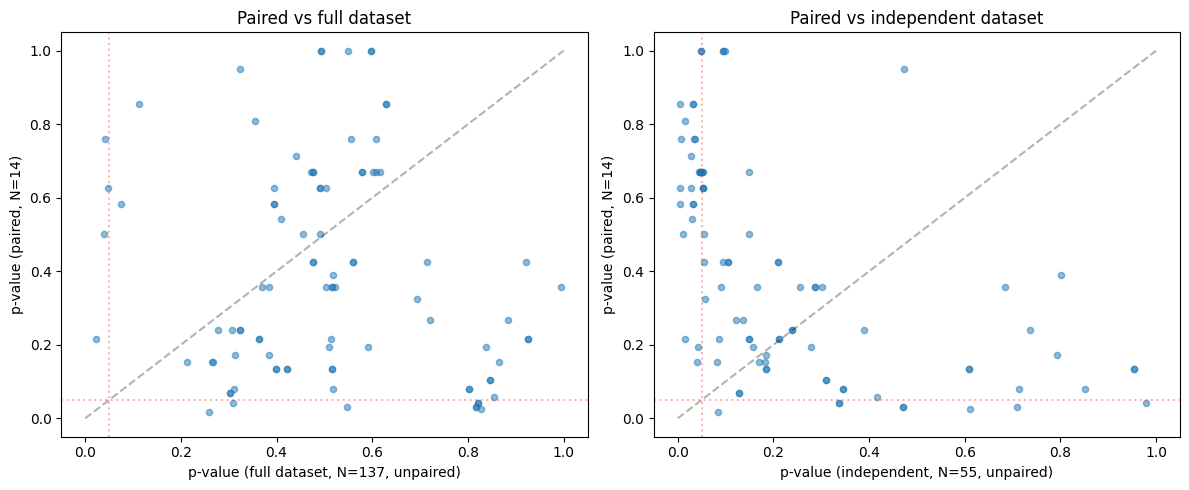

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(comparison["p_full"], comparison["p_paired"], alpha=0.5, s=20)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].axhline(0.05, color="r", linestyle=":", alpha=0.3)
axes[0].axvline(0.05, color="r", linestyle=":", alpha=0.3)
axes[0].set_xlabel("p-value (full dataset, N=137, unpaired)")
axes[0].set_ylabel("p-value (paired, N=14)")
axes[0].set_title("Paired vs full dataset")

axes[1].scatter(comparison["p_independent"], comparison["p_paired"], alpha=0.5, s=20)
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].axhline(0.05, color="r", linestyle=":", alpha=0.3)
axes[1].axvline(0.05, color="r", linestyle=":", alpha=0.3)
axes[1].set_xlabel("p-value (independent, N=55, unpaired)")
axes[1].set_ylabel("p-value (paired, N=14)")
axes[1].set_title("Paired vs independent dataset")

plt.tight_layout()
plt.savefig(os.path.join("reports", "21_pvalue_comparison_paired_normalised.png"),
            dpi=150, bbox_inches="tight")
plt.show()

## Box plots of within-patient differences

Distribution of the 14 within-patient differences (rejection - no-rejection)
for the top radiomics features and ARFI features. The horizontal line at 0
represents no difference.

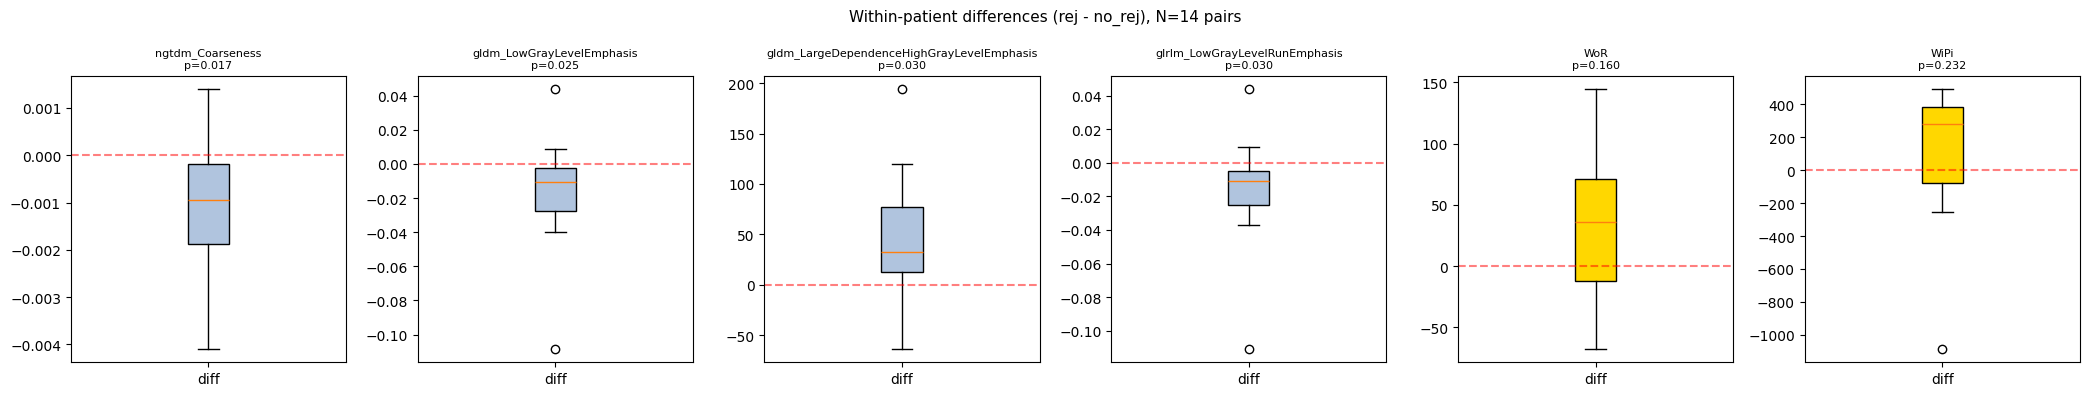

Saved to reports/21_boxplots_paired_differences_normalised.png


In [10]:
# pick top 4 radiomics features
top_rad = rad_results_df.head(4)["feature"].tolist()

# pick top 2 clinical features (likely ARFI)
top_clin = clin_results_df.head(2)["feature"].tolist()

n_plots = len(top_rad) + len(top_clin)
fig, axes = plt.subplots(1, n_plots, figsize=(3.5 * n_plots, 4))

for i, feat in enumerate(top_rad):
    d = diffs[feat].values
    bp = axes[i].boxplot([d], patch_artist=True)
    bp["boxes"][0].set_facecolor("#B0C4DE")
    axes[i].axhline(0, color="red", linestyle="--", alpha=0.5)
    short_name = feat.replace("original_", "")
    p_val = rad_results_df[rad_results_df["feature"] == feat]["p_value"].values[0]
    axes[i].set_title(f"{short_name}\np={p_val:.3f}", fontsize=8)
    axes[i].set_xticklabels(["diff"])

for j, feat in enumerate(top_clin):
    idx = len(top_rad) + j
    d = clinical_diffs[feat].dropna().values
    bp = axes[idx].boxplot([d], patch_artist=True)
    bp["boxes"][0].set_facecolor("#FFD700")
    axes[idx].axhline(0, color="red", linestyle="--", alpha=0.5)
    p_val = clin_results_df[clin_results_df["feature"] == feat]["p_value"].values[0]
    axes[idx].set_title(f"{feat}\np={p_val:.3f}", fontsize=8)
    axes[idx].set_xticklabels(["diff"])

plt.suptitle("Within-patient differences (rej - no_rej), N=14 pairs", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join("reports", "21_boxplots_paired_differences_normalised.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved to reports/21_boxplots_paired_differences_normalised.png")

## Save results

In [11]:
# save radiomics paired results
rad_output = os.path.join("reports", "21_paired_analysis_radiomics_normalised.csv")
rad_results_df.to_csv(rad_output, index=False)
print(f"Saved radiomics results to {rad_output}")

# save clinical paired results
clin_output = os.path.join("reports", "21_paired_analysis_clinical_normalised.csv")
clin_results_df.to_csv(clin_output, index=False)
print(f"Saved clinical results to {clin_output}")

# save selected pairs for reference
pairs_output = os.path.join("reports", "21_selected_pairs_normalised.csv")
pairs_df[["patient_id", "no_rej_study", "rej_study", "gap"]].to_csv(pairs_output, index=False)
print(f"Saved selected pairs to {pairs_output}")

print()
print("SUMMARY")
print(f"Paired patients: {len(pairs_df)}")
print(f"Radiomics features tested: {len(rad_results_df)}")
print(f"  Uncorrected p < 0.05: {(rad_results_df['p_value'] < 0.05).sum()}")
print(f"  FDR-corrected p < 0.05: {rad_results_df['significant_fdr'].sum()}")
print(f"Clinical features tested: {len(clin_results_df)}")
print(f"  Uncorrected p < 0.05: {(clin_results_df['p_value'] < 0.05).sum()}")

Saved radiomics results to reports/21_paired_analysis_radiomics_normalised.csv
Saved clinical results to reports/21_paired_analysis_clinical_normalised.csv
Saved selected pairs to reports/21_selected_pairs_normalised.csv

SUMMARY
Paired patients: 14
Radiomics features tested: 93
  Uncorrected p < 0.05: 8
  FDR-corrected p < 0.05: 0
Clinical features tested: 17
  Uncorrected p < 0.05: 0


## Interpretation

**Radiomics: 9 uncorrected hits, 0 after FDR.** The top feature is ngtdm_Coarseness (p=0.011), followed by 7 features tied at p=0.035 and 1 at p=0.042. None survive FDR correction (lowest adjusted p=0.28). With only 14 pairs, the Wilcoxon test has very limited resolution - many features share the same p-value because the test statistic takes discrete values with small n.

**Different features rank at the top compared to unpaired analyses.** The 9 paired-significant features (Coarseness, Imc2, SizeZoneNonUniformity, Range, GrayLevelVariance, etc.) were all non-significant in both the full dataset (p=0.34-0.98) and independent dataset (p=0.12-0.86). Conversely, the features flagged in previous analyses (firstorder_Minimum, ngtdm_Busyness, ngtdm_Strength) are not significant here. This instability across three different analysis approaches - each using different subsets and methods - confirms there is no robust radiomics signal.

**ARFI is non-significant in the paired analysis.** ARFI mediana (p=0.86) and ARFI media (p=0.91) show no within-patient difference between rejection and no-rejection studies. This contrasts sharply with the unpaired late-period analysis (NB 14b: ARFI mediana p<0.001 for studies >90 days post-transplant). Two explanations: (1) with only 12 ARFI pairs and studies spanning all timepoints, statistical power is very low; (2) the strong unpaired ARFI signal may partly reflect between-patient differences - patients who eventually develop rejection may have inherently different graft stiffness, rather than rejection itself causing measurable stiffness changes within the same patient. This second interpretation, if true, would be an important nuance for the thesis discussion.

**No clinical features reach significance.** All 17 features have p>0.05. The DCE-US features (WoR p=0.16, WiPi p=0.23) trend closer to significance than ARFI but remain non-significant with only 10 valid pairs.

**Conclusion.** The paired analysis, despite limited power, adds an important perspective: when between-patient variability is eliminated, neither radiomics nor clinical features show consistent within-patient changes associated with rejection. This is consistent with the thesis's overall finding that B-mode radiomics lack predictive value, and raises the question of whether the strong unpaired ARFI signal reflects within-patient changes (the clinically relevant mechanism) or between-patient differences (a confounder).